In [1]:
!pip install "protobuf<=3.20.3" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import time
import psutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2025-12-03 09:52:03.904274: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764755524.109113      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764755524.167724      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE_TUNE = 40
DATA_DIR = '/kaggle/input/trashnet/dataset-resized'

In [4]:
def create_dataframe(data_path):
    filepaths = []
    labels = []
    classes = sorted(os.listdir(data_path))
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        if os.path.isdir(class_path):
            for file in sorted(os.listdir(class_path)): 
                filepaths.append(os.path.join(class_path, file))
                labels.append(class_name)
    return pd.DataFrame({'filepath': filepaths, 'label': labels})

print("Processing dataset and balancing 'Trash' class...")
df = create_dataframe(DATA_DIR)
train_df, temp_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=42, stratify=temp_df['label'])
trash_samples = train_df[train_df['label'] == 'trash']
train_df_balanced = pd.concat([train_df] + [trash_samples] * 4, ignore_index=True)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Original Training Size: {len(train_df)}")
print(f"Balanced Training Size (Trash augmented): {len(train_df_balanced)}")
print(f"Data Split Summary:")
print(f"Training:   {len(train_df)} images (70%)")
print(f"Validation: {len(val_df)} images (15%)")
print(f"Testing:    {len(test_df)} images (15%)")

Processing dataset and balancing 'Trash' class...
Original Training Size: 1768
Balanced Training Size (Trash augmented): 2152
Data Split Summary:
Training:   1768 images (70%)
Validation: 379 images (15%)
Testing:    380 images (15%)


In [5]:
# VGG16 specific preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [6]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

Found 2152 validated image filenames belonging to 6 classes.


In [7]:
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 379 validated image filenames belonging to 6 classes.


In [8]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 380 validated image filenames belonging to 6 classes.


In [9]:
def build_vgg16_model(num_classes):
    # Load VGG16 with ImageNet weights, excluding the top classification layers
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(0.5)(x)
    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    
    return base_model, Model(inputs=base_model.input, outputs=predictions)

base_model, model = build_vgg16_model(num_classes=6)

# --- STAGE 1: FROZEN ---
print("\n--- STAGE 1: Training Frozen Layers (VGG16) ---")
model.compile(optimizer=Adam(learning_rate=1e-3), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history_frozen = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks
)

# --- STAGE 2: FINE-TUNING (TOP 20%) ---
print("\n--- STAGE 2: Fine-Tuning Top 20% (VGG16) ---")
base_model.trainable = True

# Calculate split point: Freeze bottom 80%
total_layers = len(base_model.layers)
freeze_until = int(total_layers * 0.80)

print(f"Total Layers: {total_layers}")
print(f"Freezing bottom {freeze_until} layers. Training top {total_layers - freeze_until} layers.")

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks
)

I0000 00:00:1764755550.086794      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764755550.087449      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- STAGE 1: Training Frozen Layers (VGG16) ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1764755556.800111      66 service.cc:148] XLA service 0x7a045c005dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764755556.801088      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764755556.801116      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764755557.382349      66 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/68 ━━━━━━━━━━━━━━━━━━━━ 17:58 16s/step - accuracy: 0.2500 - loss: 2.1421

I0000 00:00:1764755569.006443      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 ━━━━━━━━━━━━━━━━━━━━ 66s 752ms/step - accuracy: 0.5060 - loss: 1.3531 - val_accuracy: 0.7203 - val_loss: 0.8683 - learning_rate: 0.0010
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 402ms/step - accuracy: 0.7765 - loss: 0.6372 - val_accuracy: 0.7784 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 400ms/step - accuracy: 0.8127 - loss: 0.5151 - val_accuracy: 0.8127 - val_loss: 0.5799 - learning_rate: 0.0010
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 402ms/step - accuracy: 0.8569 - loss: 0.4289 - val_accuracy: 0.8153 - val_loss: 0.5204 - learning_rate: 0.0010
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 405ms/step - accuracy: 0.8700 - loss: 0.3742 - val_accuracy: 0.8391 - val_loss: 0.4802 - learning_rate: 0.0010
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 405ms/step - accuracy: 0.8650 - loss: 0.3680 - val_accuracy: 0.8496 - val_loss: 0.4997 - learning_rate: 0.0010
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 400ms/step - accuracy: 0.8999 - loss: 0.2886 - val_

In [10]:
# --- EVALUATION ---
print("\n--- Final Evaluation (VGG16 Balanced) ---")
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
target_names = list(train_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))


--- Final Evaluation (VGG16 Balanced) ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Confusion Matrix:
[[52  0  0  8  0  0]
 [ 0 65  8  0  3  0]
 [ 0  1 60  0  1  0]
 [ 1  0  5 82  1  0]
 [ 0  4  5  1 61  2]
 [ 0  0  0  4  0 16]]

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.87      0.92        60
       glass       0.93      0.86      0.89        76
       metal       0.77      0.97      0.86        62
       paper       0.86      0.92      0.89        89
     plastic       0.92      0.84      0.88        73
       trash       0.89      0.80      0.84        20

    accuracy                           0.88       380
   macro avg       0.89      0.87      0.88       380
weighted avg       0.89      0.88      0.88       380



Generating Learning Curves...


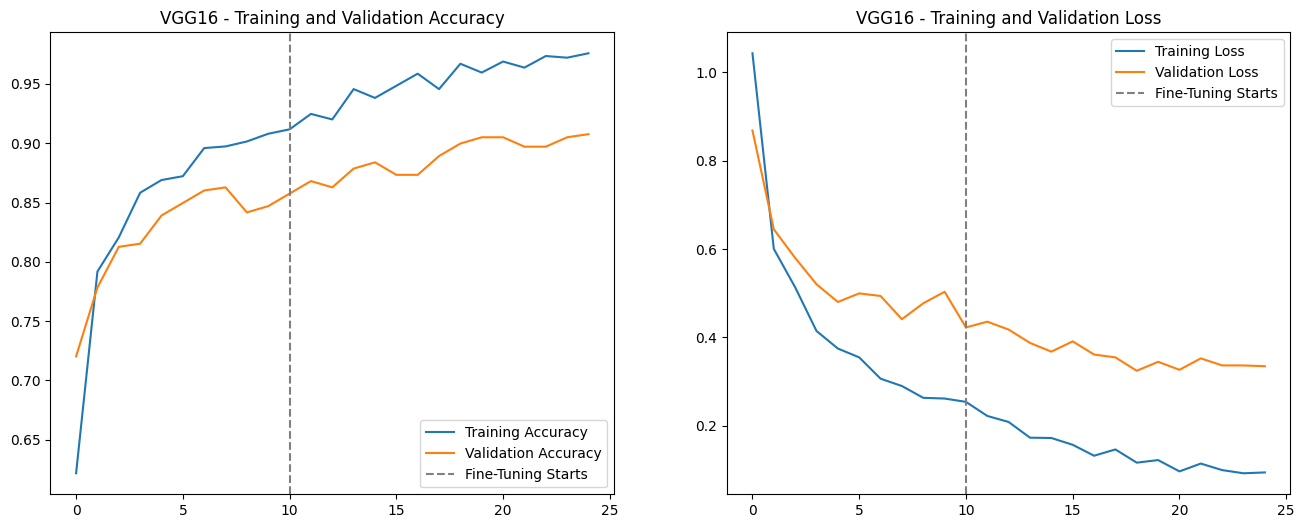

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# --- 1. PLOTTING LEARNING CURVES ---
def plot_learning_curves(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=len(hist1.history['accuracy']), color='gray', linestyle='--', label='Fine-Tuning Starts')
    plt.legend(loc='lower right')
    plt.title('VGG16 - Training and Validation Accuracy')

    # Loss Plot 
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=len(hist1.history['loss']), color='gray', linestyle='--', label='Fine-Tuning Starts')
    plt.legend(loc='upper right')
    plt.title('VGG16 - Training and Validation Loss')
    plt.show()

print("Generating Learning Curves...")
plot_learning_curves(history_frozen, history_finetune)


Generating Confusion Matrix...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step


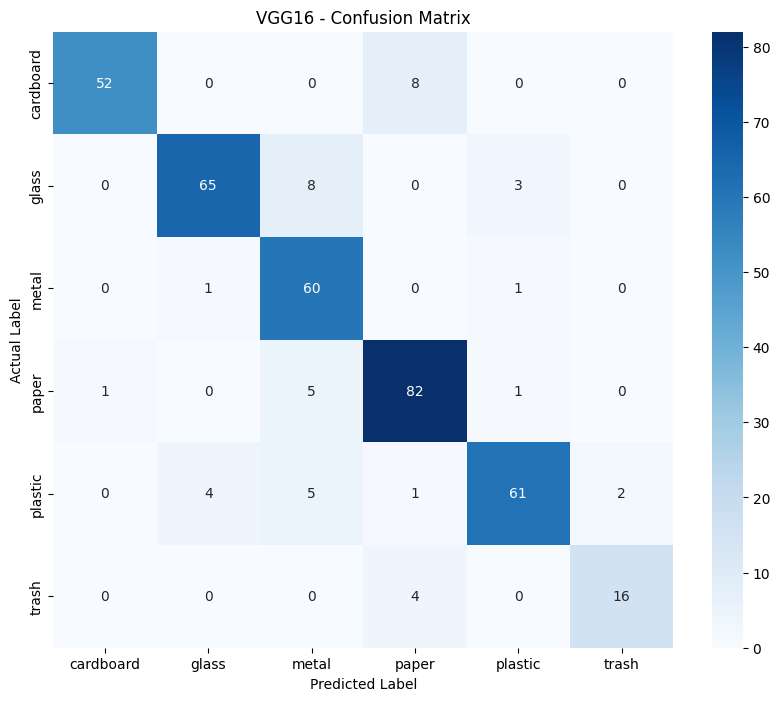

In [12]:
# --- CONFUSION MATRIX VISUALIZATION ---
print("\nGenerating Confusion Matrix...")
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('VGG16 - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [13]:
# --- DETAILED METRICS PER CLASS ---
metrics_list = []

for i, label in enumerate(class_labels):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    Total = TP + TN + FP + FN
    
    Class_Accuracy = (TP + TN) / Total
    Error_Rate = (FP + FN) / Total
    Sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    Specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    FPR = FP / (TN + FP) if (TN + FP) > 0 else 0
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    if (Precision + Sensitivity) > 0:
        F_Score = 2 * (Precision * Sensitivity) / (Precision + Sensitivity)
    else:
        F_Score = 0
        
    Prevalence = (TP + FN) / Total

    metrics_list.append({
        'Class': label,
        'Accuracy': round(Class_Accuracy, 4),
        'Error Rate': round(Error_Rate, 4),
        'Sensitivity (Recall)': round(Sensitivity, 4),
        'Specificity (TNR)': round(Specificity, 4),
        'False Pos. Rate': round(FPR, 4),
        'Precision': round(Precision, 4),
        'F-Score': round(F_Score, 4),
        'Prevalence': round(Prevalence, 4)
    })

metrics_df = pd.DataFrame(metrics_list)
print("\n--- Detailed Evaluation Metrics per Class (VGG16) ---")
print(metrics_df.to_string(index=False))

global_acc = accuracy_score(y_true, y_pred_classes)
print(f"\nGlobal Model Accuracy: {global_acc:.4f}")


--- Detailed Evaluation Metrics per Class (VGG16) ---
    Class  Accuracy  Error Rate  Sensitivity (Recall)  Specificity (TNR)  False Pos. Rate  Precision  F-Score  Prevalence
cardboard    0.9763      0.0237                0.8667             0.9969           0.0031     0.9811   0.9204      0.1579
    glass    0.9579      0.0421                0.8553             0.9836           0.0164     0.9286   0.8904      0.2000
    metal    0.9474      0.0526                0.9677             0.9434           0.0566     0.7692   0.8571      0.1632
    paper    0.9474      0.0526                0.9213             0.9553           0.0447     0.8632   0.8913      0.2342
  plastic    0.9553      0.0447                0.8356             0.9837           0.0163     0.9242   0.8777      0.1921
    trash    0.9842      0.0158                0.8000             0.9944           0.0056     0.8889   0.8421      0.0526

Global Model Accuracy: 0.8842
